# DUX Pipeline Results Explorer

## 1. Load and Parse `pipeline_results_20250705_161643.json`

In [36]:

import json

file_path = 'watch_folders/hitl_review/pipeline_results_20250705_161643.json'

with open(file_path, 'r') as f:
    data = json.load(f)

print("JSON file loaded successfully.")


JSON file loaded successfully.


## 2. Display Pipeline Statistics

In [37]:

pipeline_stats = data.get('pipeline_stats', {})

for key, value in pipeline_stats.items():
    print(f"{key.replace('_', ' ').title()}: {value}")


Total Raw Objects: 1541
Attracted Objects: 0
Validated Objects: 0
Fit Templates Used: 0
One Sheets Generated: 8
Processing Time Seconds: 0.04056096076965332


In [38]:

raw_data_summary = data.get('raw_data_summary', {})
sources = raw_data_summary.get('sources', [])

print(f"Total number of sources: {len(sources)}")

for source in sources:
    print(source)


Total number of sources: 65
output_7.3.2025_v001.md
insight.md
ROSwell_objects.md
ROS_BlueprintFitTemplate.md
filter_template.md
insight_chain_kubeflow2.0.md
README.md
fit_template_prompt_protocol (2).md
fit_template_protocol_FitPhase_v_2.md
insights_02.md
ROSwellInsightsv1.md
20250704_234927_01_fit_template_promptROS_TCOA_RHOAIoutcomes.md
20250705_000045_notebooklm_protocol_v_9.5_refactored.md
20250704_225732_0001_fit_template.md
20250705_000045_0001_fit_template.md
20250704_230317_fit_template_primer_v_1.md
20250704_234927_03_fit_template_customer_journey_map_AI.md
20250705_000045_notebooklm_protocol_v_9.5_unified.md
20250705_001026_0001_fit_template.md
20250704_234927_cognitive_sequencing_primer_with_schema_v9.5.md
20250704_225732_fit_template_primer_v_1.md
20250705_001026_03_json_objects_customer_journe_map_AI.md
20250705_000045_02_objects_MCMPROSwell.md
20250705_001026_02_objects_MCMPROSwell.md
20250704_225732_03_fit_template_customer_journey_map_AI.md
20250704_225732_02_objects_M

## 3. Analyze Raw Data Sources

In [39]:

raw_objects = data.get('raw_objects', [])

if raw_objects:
    from pprint import pprint
    pprint(raw_objects[0])
else:
    print("No raw objects found in the data.")


No raw objects found in the data.


## 4. Summarize Magnet Results

In [40]:

magnet_results = data.get('magnet_results', {})

for template, summary in magnet_results.get('summary_by_template', {}).items():
    print(f"--- {template} ---")
    print(f"Fit Quality: {summary.get('fit_quality')}")
    print(f"Thematic Alignment: {summary.get('thematic_alignment')}")
    print("Gaps Identified:")
    for gap in summary.get('gaps_identified', []):
        print(f"- {gap}")
    print("\n")


--- Cost Management ---
Fit Quality: No objects evaluated
Thematic Alignment: No matched objects to analyze
Gaps Identified:
- Missing Problem objects
- Missing Behavior objects
- Missing Result objects


--- Kubeflow Bella ---
Fit Quality: No objects evaluated
Thematic Alignment: No matched objects to analyze
Gaps Identified:
- Missing Problem objects
- Missing Behavior objects
- Missing Result objects


--- Operating Models Purpose ---
Fit Quality: No objects evaluated
Thematic Alignment: No matched objects to analyze
Gaps Identified:
- Missing Problem objects
- Missing Behavior objects
- Missing Result objects




## 5. Visualize One Sheet Insights

In [41]:

one_sheets = data.get('one_sheets', [])

for sheet in one_sheets:
    print(f"--- {sheet.get('title')} ---")
    print(f"Source: {sheet.get('template_source')}")
    print(f"Executive Summary: {sheet.get('executive_summary')}")
    print("Recommendations:")
    for rec in sheet.get('recommendations', []):
        print(f"- {rec}")
    print("Metrics:")
    for key, value in sheet.get('metrics', {}).items():
        print(f"- {key.replace('_', ' ').title()}: {value}")
    print("\n")


--- Cost Management - Strategic Insights ---
Source: Cost Management
Executive Summary: Based on the Cost Management fit template analysis, we processed 0 objects 
and achieved No objects evaluated fit quality with 0 validated matches. 
The analysis reveals key patterns in cost management that can drive strategic decisions.
Recommendations:
- Investigate Cost Management alignment issues before proceeding
- Address identified gaps: Missing Problem objects, Missing Behavior objects, Missing Result objects
- Focus on primary themes: No matched objects to analyze
Metrics:
- Objects Analyzed: 0
- Fit Quality: No objects evaluated
- Confidence Level: Low


--- Kubeflow Bella - Strategic Insights ---
Source: Kubeflow Bella
Executive Summary: Based on the Kubeflow Bella fit template analysis, we processed 0 objects 
and achieved No objects evaluated fit quality with 0 validated matches. 
The analysis reveals key patterns in kubeflow bella that can drive strategic decisions.
Recommendations:
- 

## 6. Aggregate and Visualize Key Metrics

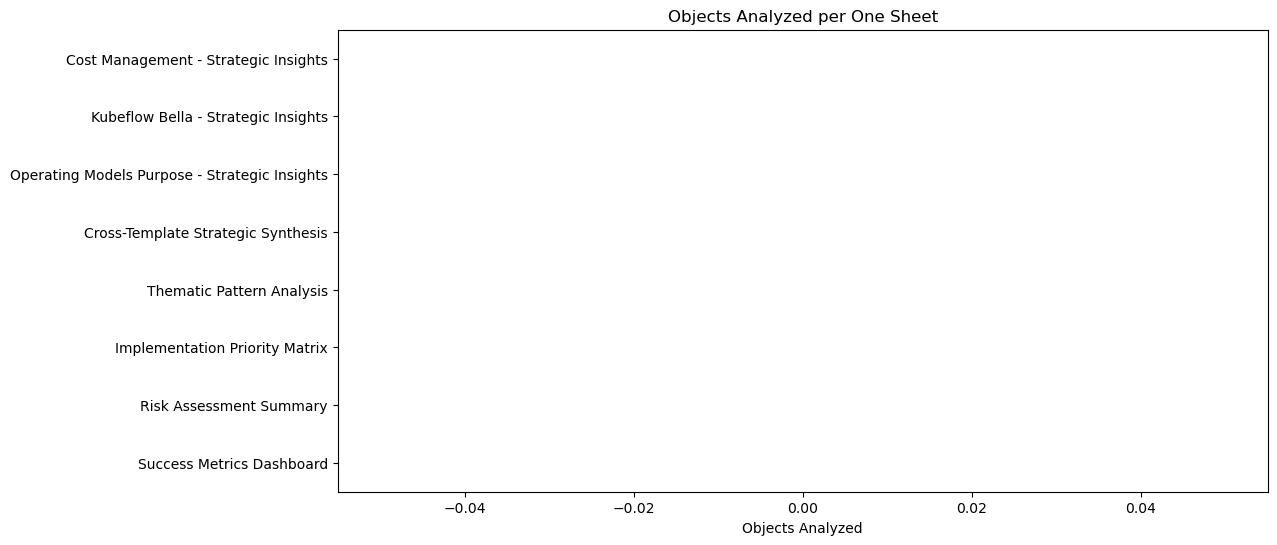

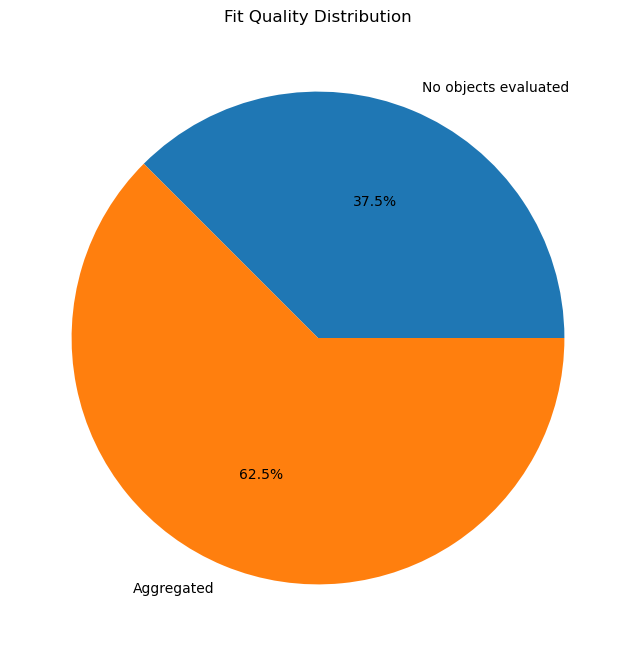

In [42]:

import matplotlib.pyplot as plt
import seaborn as sns

# Example visualization: Bar chart of objects_analyzed per one sheet

objects_analyzed = [sheet.get('metrics', {}).get('objects_analyzed', 0) for sheet in one_sheets]
titles = [sheet.get('title') for sheet in one_sheets]

plt.figure(figsize=(12, 6))
sns.barplot(x=objects_analyzed, y=titles)
plt.xlabel("Objects Analyzed")
plt.title("Objects Analyzed per One Sheet")
plt.show()

# Example visualization: Pie chart of fit_quality distribution

fit_quality = [sheet.get('metrics', {}).get('fit_quality') for sheet in one_sheets]
fit_quality_counts = {quality: fit_quality.count(quality) for quality in set(fit_quality)}

plt.figure(figsize=(8, 8))
plt.pie(fit_quality_counts.values(), labels=fit_quality_counts.keys(), autopct='%1.1f%%')
plt.title("Fit Quality Distribution")
plt.show()



## 7. Validate Output Against Technical Specification


In [ ]:

!pip install jsonschema


In [ ]:

import jsonschema

# Define the JSON schema based on the technical specification
pipeline_output_schema = {
    "$schema": "http://json-schema.org/draft-07/schema#",
    "title": "DUX Pipeline Results",
    "description": "Schema for the complete raw data and processing results from the DUX Fit Template Magnet System pipeline.",
    "type": "object",
    "properties": {
        "pipeline_stats": {
            "type": "object",
            "properties": {
                "total_raw_objects": {"type": "integer"},
                "attracted_objects": {"type": "integer"},
                "validated_objects": {"type": "integer"},
                "fit_templates_used": {"type": "integer"},
                "one_sheets_generated": {"type": "integer"},
                "processing_time_seconds": {"type": "number"}
            },
            "required": ["total_raw_objects", "attracted_objects", "validated_objects", "fit_templates_used", "one_sheets_generated", "processing_time_seconds"]
        },
        "raw_data_summary": {
            "type": "object",
            "properties": {
                "total_objects": {"type": "integer"},
                "sources": {"type": "array", "items": {"type": "string"}}
            },
            "required": ["total_objects", "sources"]
        },
        "magnet_results": {
            "type": "object",
            "properties": {
                "total_attracted": {"type": "integer"},
                "total_validated": {"type": "integer"},
                "processing_time": {"type": "number"},
                "attracted_by_template": {
                    "type": "object",
                    "additionalProperties": {
                        "type": "array",
                        "items": {"type": "object"}
                    }
                },
                "summary_by_template": {
                    "type": "object",
                    "additionalProperties": {
                        "type": "object"
                    }
                }
            }
        },
        "one_sheets": {
            "type": "array",
            "items": {"type": "object"}
        },
        "raw_objects": {
            "type": "array",
            "items": {"type": "object"}
        }
    },
    "required": ["pipeline_stats", "raw_data_summary", "magnet_results", "one_sheets", "raw_objects"]
}

try:
    jsonschema.validate(instance=data, schema=pipeline_output_schema)
    print("✅ JSON output is valid against the technical specification.")
except jsonschema.exceptions.ValidationError as err:
    print("❌ JSON output is INVALID against the technical specification.")
    print(f"Validation Error: {err.message}")
    print(f"On instance: {err.instance}")
    print(f"At path: {list(err.path)}")
except jsonschema.exceptions.SchemaError as err:
    print("❌ The JSON schema itself is invalid.")
    print(f"Schema Error: {err.message}")




### 7.1 Validate Individual Raw Objects


In [ ]:

# Define a more detailed schema for the raw objects based on the spec
raw_object_schema = {
    "$schema": "http://json-schema.org/draft-07/schema#",
    "title": "DUX Raw Object",
    "description": "Schema for individual DUX objects (Problem, Behavior, Result, etc.).",
    "type": "object",
    "properties": {
        "object_type": {"type": "string", "enum": ["Behavior", "Problem", "Result", "Insight", "Provenance"]},
        "id": {"type": "string"},
        "evidence": {"type": "array"},
        "_source_filename": {"type": "string"},
        "_parsed_at": {"type": "string", "format": "date-time"}
    },
    "required": ["object_type", "id", "_source_filename", "_parsed_at"],
    "if": {"properties": {"object_type": {"const": "Behavior"}}},
    "then": {
        "properties": {
            "user_enablement": {"type": "string"},
            "behavior_type": {"type": "string"},
            "signals": {"type": "array", "items": {"type": "string"}},
            "acceptance_criteria": {"type": "string"}
        },
        "required": ["user_enablement"]
    },
    "if": {"properties": {"object_type": {"const": "Problem"}}},
    "then": {
        "properties": {
            "job_statement": {"type": "string"}
        },
        "required": ["job_statement"]
    },
    "if": {"properties": {"object_type": {"const": "Result"}}},
    "then": {
        "properties": {
            "target_impact": {"type": "string"},
            "success_metrics": {"type": "array", "items": {"type": "string"}}
        },
        "required": ["target_impact"]
    },
    "if": {"properties": {"object_type": {"const": "Insight"}}},
    "then": {
        "properties": {
            "insight_teaser": {"type": "string"},
            "insight_chain": {
                "type": "object",
                "properties": {
                    "problem_id": {"type": "string"},
                    "behavior_id": {"type": "string"},
                    "result_id": {"type": "string"}
                },
                "required": ["problem_id", "behavior_id", "result_id"]
            }
        },
        "required": ["insight_teaser"]
    }
}


validated_count = 0
invalid_count = 0
validation_errors = []

raw_objects = data.get('raw_objects', [])

for i, obj in enumerate(raw_objects):
    try:
        jsonschema.validate(instance=obj, schema=raw_object_schema)
        validated_count += 1
    except jsonschema.exceptions.ValidationError as err:
        invalid_count += 1
        validation_errors.append({
            "object_index": i,
            "object_id": obj.get('id', 'N/A'),
            "error": err.message
        })

print(f"--- Raw Object Validation Summary ---")
print(f"✅ Valid objects: {validated_count}")
print(f"❌ Invalid objects: {invalid_count}")

if validation_errors:
    print("\n--- First 5 Validation Errors ---")
    from pprint import pprint
    pprint(validation_errors[:5])

